# ModHav Synthetic Dataset

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import ModHav_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

In [2]:
# ── 1. Data Import ────────────────────────────────────────────────────────────
X, y = ModHav_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

print(f"Dataset  : ModHav Synthetic, 20 per class")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/ModHav Synthetic'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : ModHav Synthetic, 20 per class
Train    : (28, 4)  |  Test: (12, 4)


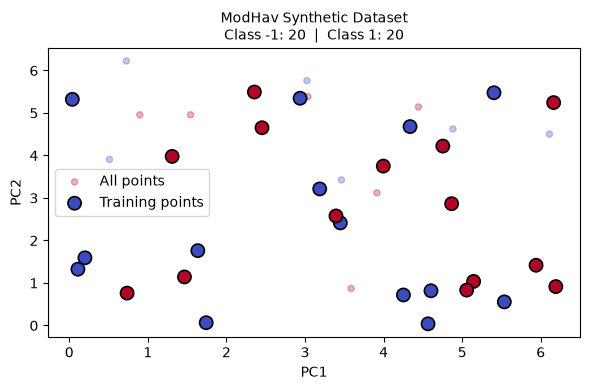

In [3]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset("ModHav Synthetic", X, y, X_train, y_train)

In [7]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric' or 'haar'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    # ──– OPTUNA ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'optuna',
        optimizer        = 'optuna',
        variant          = 'haar',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    ),
    
    ExperimentConfig(
        name             = 'optuna2',
        optimizer        = 'optuna',
        variant          = 'haar',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    )
]

In [8]:
# ── 4. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-08-20 12:53:42,307] A new study created in memory with name: no-name-9c63d193-911a-4504-a2cd-0ca84d8a7923



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna'
Loading cached SVM results for 'optuna'

────────────────────────────────────────────────────────────
 optuna2  [optuna + none]
────────────────────────────────────────────────────────────


[I 2026-08-20 12:53:44,759] Trial 0 finished with value: 7.1954168608811955 and parameters: {'gate_0': 'RX', 'gate_1': 'CNOT', 'gate_2': 'RZ', 'gate_3': 'CNOT', 'gate_4': 'RZ', 'gate_5': 'RY', 'gate_6': 'CNOT', 'gate_7': 'H', 'gate_8': 'CNOT', 'gate_9': 'I', 'gate_10': 'RX', 'gate_11': 'I', 'gate_12': 'RX', 'gate_13': 'CNOT', 'gate_14': 'I', 'gate_15': 'RZ'}. Best is trial 0 with value: 7.1954168608811955.
[I 2026-08-20 12:53:47,152] Trial 1 finished with value: 6.064256919406774 and parameters: {'gate_0': 'CNOT', 'gate_1': 'H', 'gate_2': 'RZ', 'gate_3': 'H', 'gate_4': 'H', 'gate_5': 'H', 'gate_6': 'RX', 'gate_7': 'CNOT', 'gate_8': 'RY', 'gate_9': 'CNOT', 'gate_10': 'RZ', 'gate_11': 'I', 'gate_12': 'CNOT', 'gate_13': 'H', 'gate_14': 'RZ', 'gate_15': 'RY'}. Best is trial 0 with value: 7.1954168608811955.
[I 2026-08-20 12:53:49,465] Trial 2 finished with value: 7.273855352699582 and parameters: {'gate_0': 'RX', 'gate_1': 'RX', 'gate_2': 'RY', 'gate_3': 'I', 'gate_4': 'I', 'gate_5': 'CNOT

Saved candidate  → Results/ModHav Synthetic/optuna2/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/ModHav Synthetic/optuna2/svm.pkl

REPORT: optuna2 | 100 trials
Best C            : 0.1
Best CV accuracy  : 0.8333
Test accuracy     : 0.5833
              precision    recall  f1-score   support

          -1       0.60      0.50      0.55         6
           1       0.57      0.67      0.62         6

    accuracy                           0.58        12
   macro avg       0.59      0.58      0.58        12
weighted avg       0.59      0.58      0.58        12



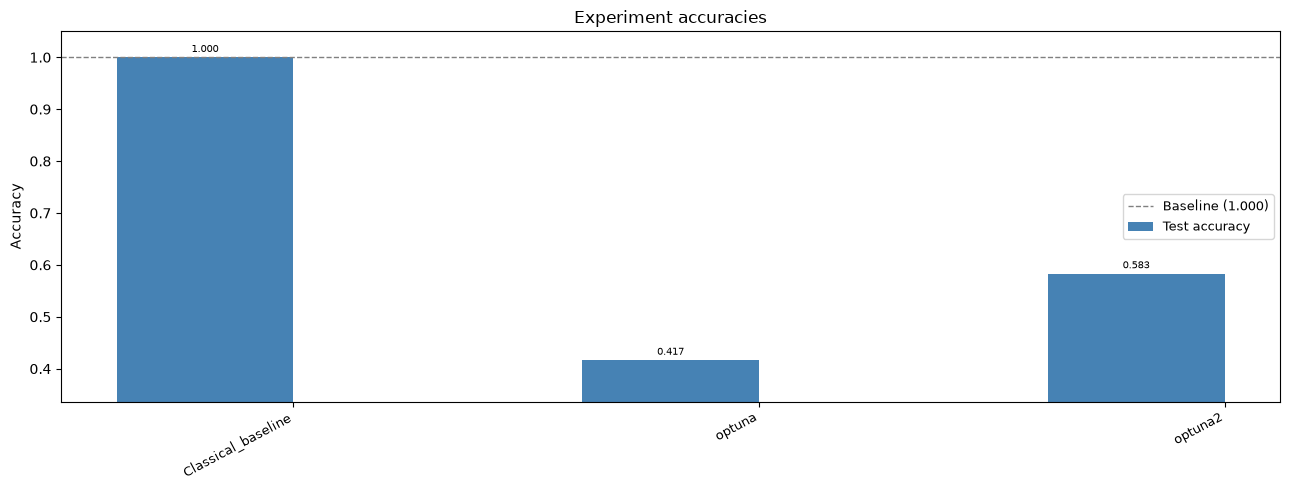

Saved → Results/ModHav Synthetic/accuracy_comparison.png


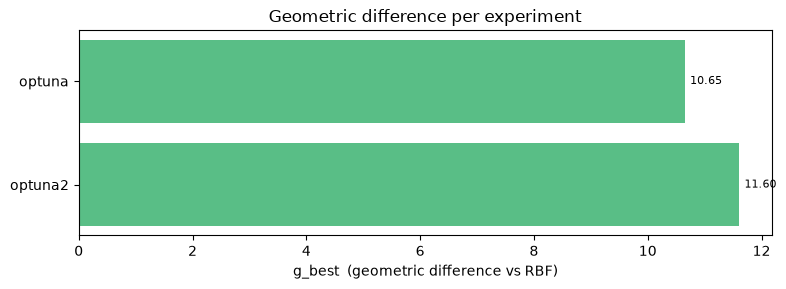

Saved → Results/ModHav Synthetic/g_best_comparison.png


In [9]:
# ── 6. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)